## 1. Importações e Configurações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 2. Carregamento dos Dados

### Contexto de Negócio

Os dados analisados compreendem **o e-commerce brasileiro** entre 2016 e 2018, representando:
- **99.441 pedidos** realizados na plataforma Olist
- **112.650 itens** vendidos
- **103.886 pagamentos** processados
- **99.224 avaliações** de clientes

Este dataset é uma janela única para entender o comportamento do consumidor digital brasileiro no período de expansão do e-commerce nacional.

In [2]:
df_orders    = pd.read_csv('olist_orders_dataset.csv', encoding='utf-8')
df_items     = pd.read_csv('olist_order_items_dataset.csv', encoding='utf-8')
df_payments  = pd.read_csv('olist_order_payments_dataset.csv', encoding='utf-8')
df_reviews   = pd.read_csv('olist_order_reviews_dataset.csv', encoding='utf-8')
df_customers = pd.read_csv('olist_customers_dataset.csv', encoding='utf-8')
df_sellers   = pd.read_csv('olist_sellers_dataset.csv', encoding='utf-8')
df_products  = pd.read_csv('olist_products_dataset.csv', encoding='utf-8')
df_geo       = pd.read_csv('olist_geolocation_dataset.csv', encoding='utf-8')
df_cat_transl = pd.read_csv('product_category_name_translation.csv', encoding='utf-8')

print(f"Pedidos      : {len(df_orders):,} registros")
print(f"Itens        : {len(df_items):,} registros")
print(f"Pagamentos   : {len(df_payments):,} registros")
print(f"Avaliações   : {len(df_reviews):,} registros")
print(f"Clientes     : {len(df_customers):,} registros")
print(f"Vendedores   : {len(df_sellers):,} registros")
print(f"Produtos     : {len(df_products):,} registros")

Pedidos      : 99,441 registros
Itens        : 112,650 registros
Pagamentos   : 103,886 registros
Avaliações   : 99,224 registros
Clientes     : 99,441 registros
Vendedores   : 3,095 registros
Produtos     : 32,951 registros


## 3. Qualidade dos Dados

### Insight de Negócio

A análise de valores nulos revela a **maturidade operacional** do e-commerce brasileiro:

**Pontos-Chave:**
- Colunas de datas de entrega como `order_delivered_carrier_date` e `order_delivered_customer_date` possuem nulos esperados para pedidos cancelados ou em andamento
- `review_comment_title` com 88% de nulos indica que o cliente brasileiro raramente adiciona título textual à avaliação — prefere apenas a nota
- `product_category_name` com 1.9% de nulos pode impactar análises de categoria

**Impacto para Negócios:**
- Pedidos sem data de entrega representam oportunidade de melhoria operacional
- Alta taxa de avaliações sem texto limita análise de NLP, mas a nota numérica é confiável
- Produtos sem categoria precisam ser catalogados para análises de mix de produtos

In [3]:
nulos_orders = df_orders.isnull().sum()
nulos_pct = (nulos_orders / len(df_orders) * 100).round(2)

nulos_df = pd.DataFrame({
    'Coluna': nulos_orders.index,
    'Valores Nulos': nulos_orders.values,
    'Percentual (%)': nulos_pct.values
})

nulos_df[nulos_df['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

,Coluna,Valores Nulos,Percentual (%)
6,order_delivered_customer_date,2965,2.98
5,order_delivered_carrier_date,1783,1.79
4,order_approved_at,160,0.16


## 4. Análise Temporal: Evolução dos Pedidos

### 4.1. Crescimento Mensal de Pedidos

**Insight de Negócio:**

A curva de pedidos ao longo do tempo revela a **trajetória de crescimento** do e-commerce brasileiro:

- **2016**: Fase embrionária com poucos pedidos — plataforma ainda em consolidação
- **2017**: Crescimento acelerado, impulsionado pela popularização do acesso mobile e internet no Brasil
- **2018**: Pico de maturidade — volumes mensais chegam a superar 7.000 pedidos
- **Nov/Dez 2017**: Saltos pronunciados evidenciam o impacto da **Black Friday e Natal** no volume de vendas

**Implicações Comerciais:**
- Sazonalidade exige preparação de estoque e logística 60 dias antes do Q4
- A taxa de crescimento composta (CAGR) indica mercado em expansão: momento ideal para investimento em capacidade operacional

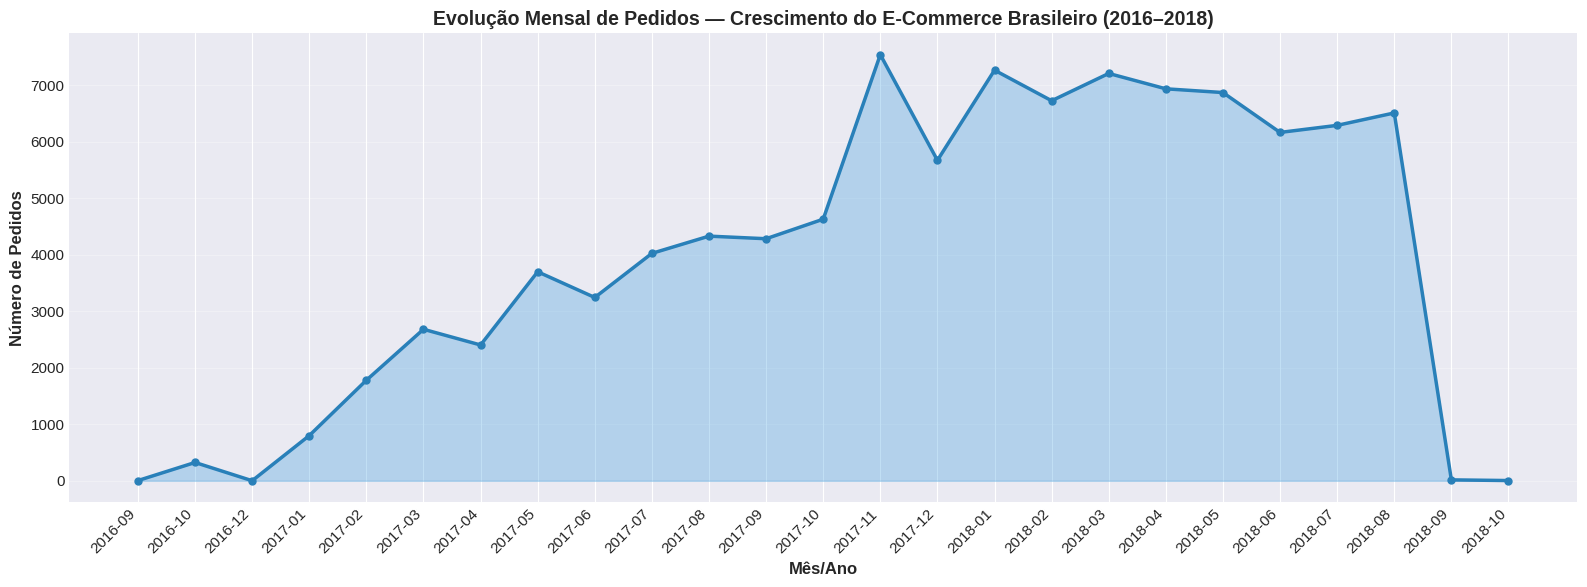

Média de pedidos/mês: 3978
Mês com mais pedidos: 2017-11 (7,544 pedidos)
Crescimento total (início → pico): 188500%


In [4]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['ano_mes'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
df_orders['ano'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['mes'] = df_orders['order_purchase_timestamp'].dt.month
df_orders['dia_semana'] = df_orders['order_purchase_timestamp'].dt.day_name()

pedidos_mensais = df_orders.groupby('ano_mes').size().reset_index(name='pedidos')
pedidos_mensais['ano_mes_str'] = pedidos_mensais['ano_mes'].astype(str)

plt.figure(figsize=(16, 6))
plt.fill_between(range(len(pedidos_mensais)), pedidos_mensais['pedidos'], alpha=0.3, color='#3498db')
plt.plot(range(len(pedidos_mensais)), pedidos_mensais['pedidos'], color='#2980b9', linewidth=2.5, marker='o', markersize=5)
plt.xticks(range(len(pedidos_mensais)), pedidos_mensais['ano_mes_str'], rotation=45, ha='right')
plt.xlabel('Mês/Ano', fontsize=12, fontweight='bold')
plt.ylabel('Número de Pedidos', fontsize=12, fontweight='bold')
plt.title('Evolução Mensal de Pedidos — Crescimento do E-Commerce Brasileiro (2016–2018)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Média de pedidos/mês: {pedidos_mensais['pedidos'].mean():.0f}")
print(f"Mês com mais pedidos: {pedidos_mensais.loc[pedidos_mensais['pedidos'].idxmax(), 'ano_mes_str']} ({pedidos_mensais['pedidos'].max():,} pedidos)")
print(f"Crescimento total (início → pico): {((pedidos_mensais['pedidos'].max() / pedidos_mensais['pedidos'].iloc[0]) - 1)*100:.0f}%")

### 4.2. Distribuição de Pedidos por Dia da Semana

**Análise de Negócio:**

O padrão de compras por dia da semana reflete o **comportamento digital** do consumidor brasileiro:

**Segunda e Terça: Os Dias Campeões**
- Maior volume de pedidos — o consumidor decide comprar no início da semana
- Hipótese: pesquisa feita no fim de semana, decisão de compra efetivada na segunda

**Fim de Semana: Queda Relativa**
- Sábado e domingo apresentam volumes menores
- Competição com atividades de lazer e compras físicas

**Recomendações Estratégicas:**
1. **E-mail marketing e push notifications**: Disparar campanhas na sexta-feira para capturar decisões do fim de semana
2. **Logística**: Dimensionar operação de separação de pedidos para pico de segunda e terça
3. **Promoções**: Campanhas de "Cyber Monday" têm aderência natural ao comportamento já identificado

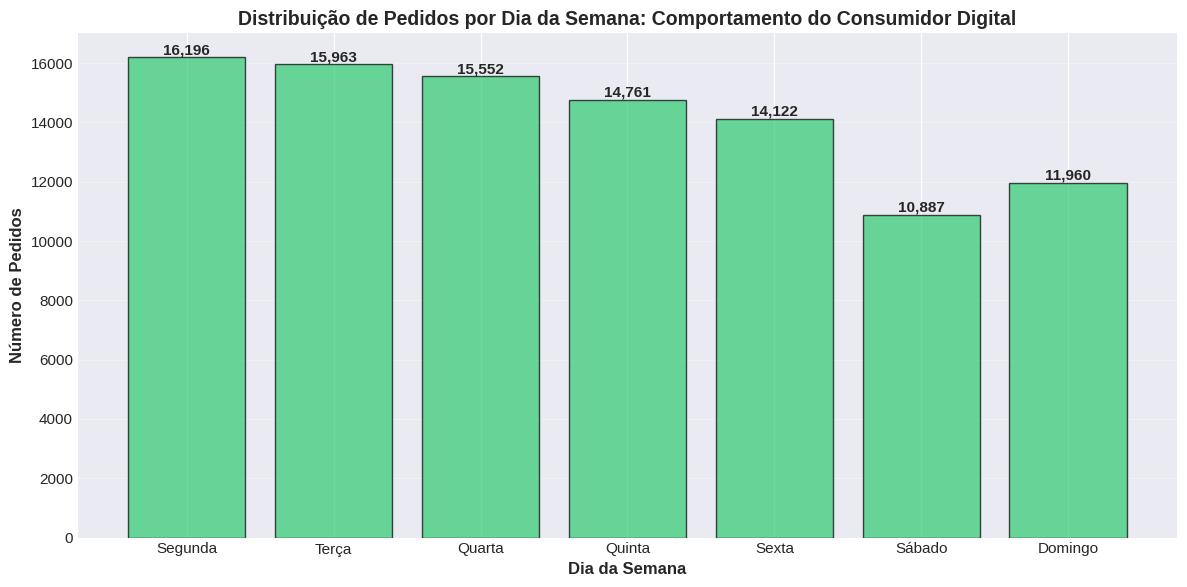

Distribuição Percentual:
   Segunda    16,196 pedidos ( 16.3%)
   Terça      15,963 pedidos ( 16.1%)
   Quarta     15,552 pedidos ( 15.6%)
   Quinta     14,761 pedidos ( 14.8%)
   Sexta      14,122 pedidos ( 14.2%)
   Sábado     10,887 pedidos ( 10.9%)
   Domingo    11,960 pedidos ( 12.0%)


In [5]:
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

pedidos_dia = df_orders['dia_semana'].value_counts().reindex(ordem_dias)

plt.figure(figsize=(12, 6))
bars = plt.bar(dias_pt, pedidos_dia.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.xlabel('Dia da Semana', fontsize=12, fontweight='bold')
plt.ylabel('Número de Pedidos', fontsize=12, fontweight='bold')
plt.title('Distribuição de Pedidos por Dia da Semana: Comportamento do Consumidor Digital', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Distribuição Percentual:")
for dia_en, dia_pt_nome, valor in zip(ordem_dias, dias_pt, pedidos_dia.values):
    pct = (valor / pedidos_dia.sum()) * 100
    print(f"   {dia_pt_nome:10} {valor:6,} pedidos ({pct:5.1f}%)")

## 5. Análise Geográfica: O Mapa do E-Commerce Brasileiro

### 5.1. Volume de Pedidos por Estado

**Insight Estratégico:**

A distribuição geográfica revela a **concentração e as oportunidades** do mercado digital brasileiro:

- **São Paulo: O Gigante Absoluto** — representa mais de 40% de todos os pedidos. PIB, densidade populacional e cultura digital mais avançada explicam essa dominância
- **Rio de Janeiro e Minas Gerais**: Completam o pódio, formando o eixo Sudeste que sozinho representa ~65% do e-commerce nacional
- **Norte e Centro-Oeste**: Volumes muito menores indicam **mercados inexplorados** com potencial de crescimento superior à média

**Oportunidades de Negócio:**
- **Expansão logística**: Investir em hubs no Nordeste (BA, PE, CE) pode capturar mercado crescente
- **Personalização regional**: Produtos e comunicação adaptados a cada região aumentam conversão
- **Precificação de frete**: Estados distantes exigem estratégia de subsídio de frete para competitividade

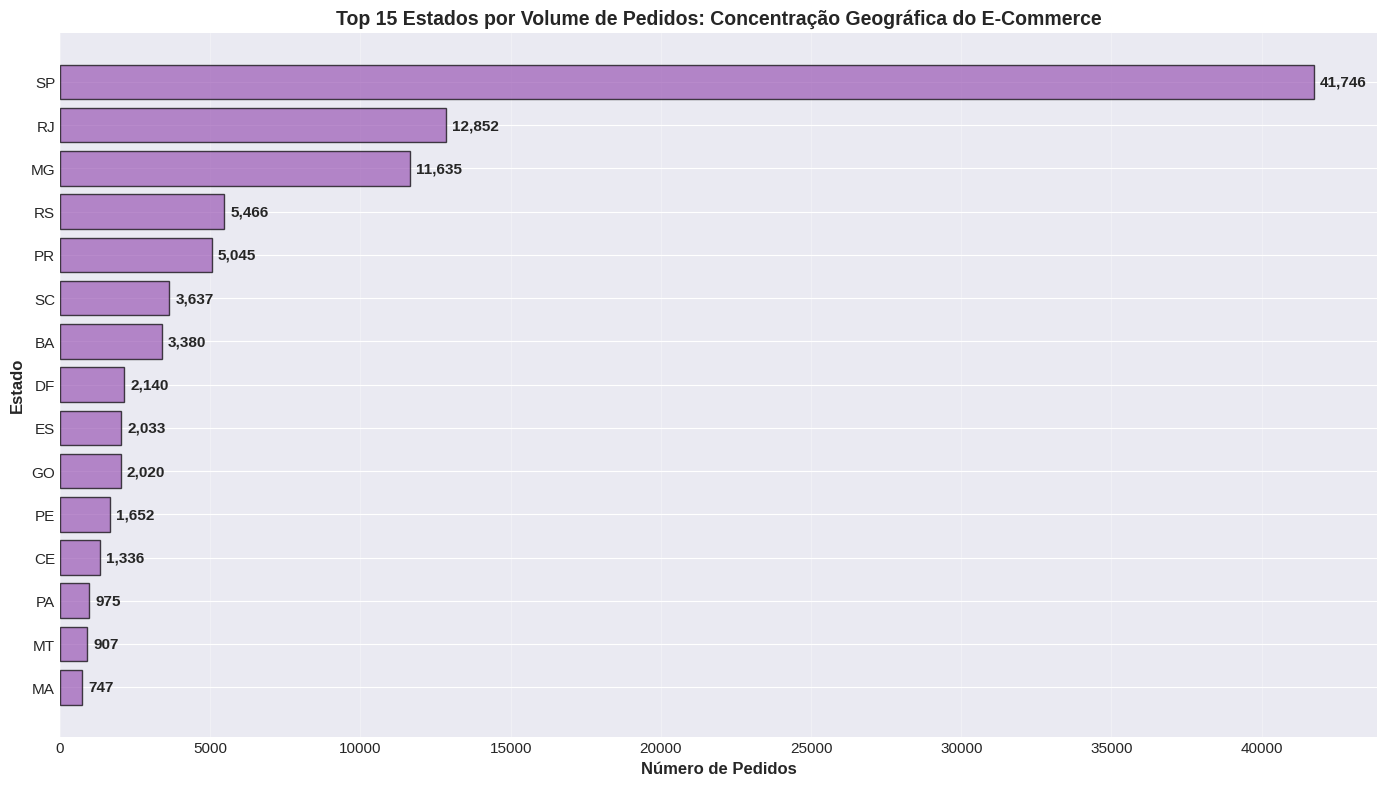

Estado líder: SP com 41,746 pedidos (43.7% do total)
Top 3 estados concentram: 69.3% dos pedidos


In [6]:
pedidos_com_cliente = df_orders.merge(df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
pedidos_por_estado = pedidos_com_cliente['customer_state'].value_counts().head(15)

plt.figure(figsize=(14, 8))
plt.barh(range(len(pedidos_por_estado)), pedidos_por_estado.values, color='#9b59b6', edgecolor='black', alpha=0.7)
plt.yticks(range(len(pedidos_por_estado)), pedidos_por_estado.index)
plt.xlabel('Número de Pedidos', fontsize=12, fontweight='bold')
plt.ylabel('Estado', fontsize=12, fontweight='bold')
plt.title('Top 15 Estados por Volume de Pedidos: Concentração Geográfica do E-Commerce', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(pedidos_por_estado.values):
    plt.text(v + 200, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

total = pedidos_por_estado.sum()
print(f"Estado líder: {pedidos_por_estado.index[0]} com {pedidos_por_estado.values[0]:,} pedidos ({pedidos_por_estado.values[0]/total*100:.1f}% do total)")
print(f"Top 3 estados concentram: {pedidos_por_estado.values[:3].sum()/total*100:.1f}% dos pedidos")

## 6. Performance Financeira

### 6.1. Receita por Categoria de Produto

**Análise Estratégica:**

O ranking de receita por categoria expõe o **mix de negócio real** da plataforma:

- **Beleza & Saúde, Camas/Mesas/Banho e Esportes**: Lideram em receita, indicando que o consumidor brasileiro privilegia produtos de bem-estar e casa no digital
- **Informática e Eletrônicos**: Alto ticket médio compensa menor volume de pedidos
- **Categorias de cauda longa**: Dezenas de categorias com volumes menores representam oportunidade de curadoria e estratégia de sortimento

**Implicações Comerciais:**
- **Gestão de categoria**: Investir em exposição das top categorias maximiza receita por sessão
- **Pricing**: Categorias de ticket alto exigem estratégia de parcelamento agressiva
- **Logística reversa**: Categorias de vestuário têm maior taxa de devolução — custo oculto a considerar

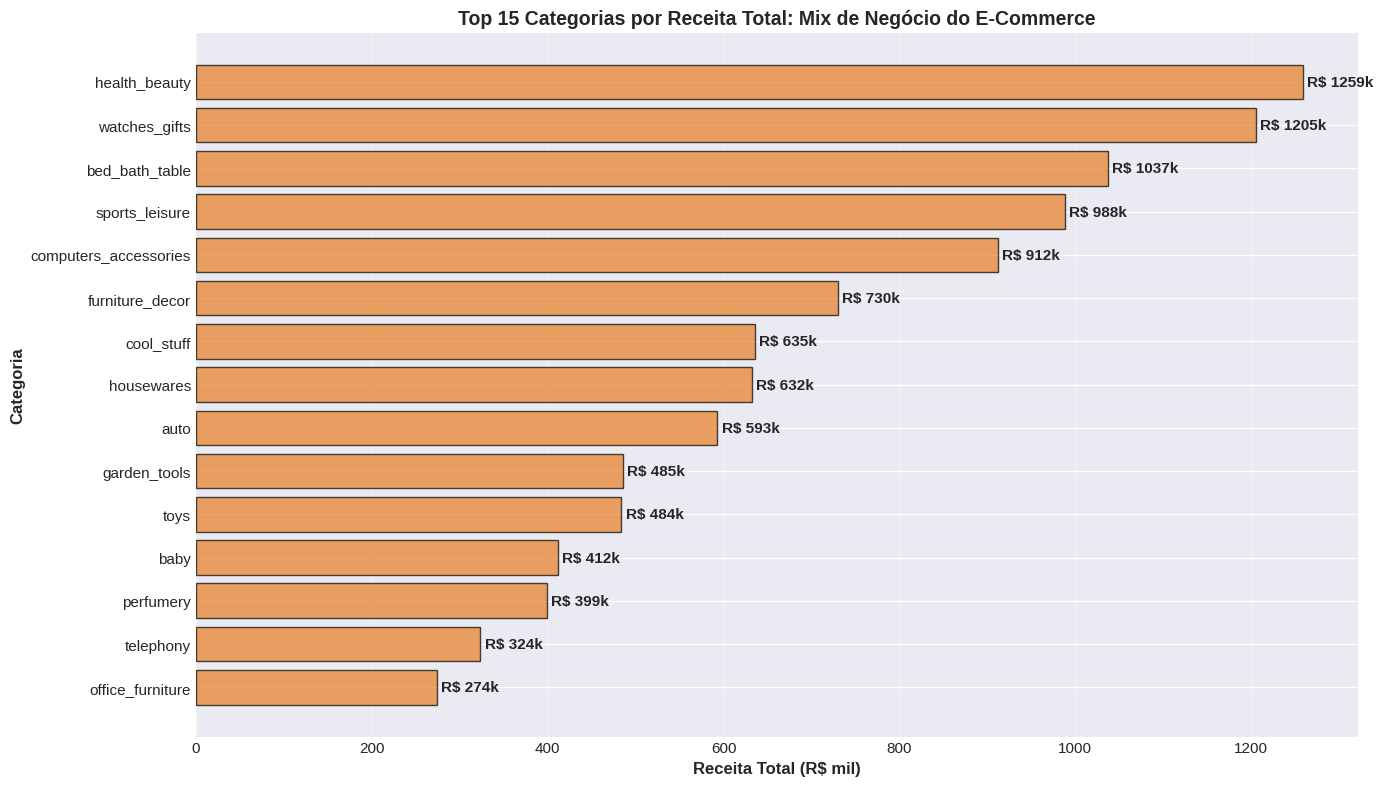

Receita total da plataforma: R$ 13,591,644
Categoria líder: health_beauty — R$ 1,258,681
Top 3 categorias representam: 25.8% da receita


In [7]:
items_com_produto = df_items.merge(df_products[['product_id', 'product_category_name']], on='product_id', how='left')
items_com_produto = items_com_produto.merge(df_cat_transl, on='product_category_name', how='left')
items_com_produto['categoria'] = items_com_produto['product_category_name_english'].fillna(
    items_com_produto['product_category_name'].fillna('sem_categoria')
)

receita_por_categoria = items_com_produto.groupby('categoria')['price'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 8))
plt.barh(range(len(receita_por_categoria)), receita_por_categoria.values / 1e3, color='#e67e22', edgecolor='black', alpha=0.7)
plt.yticks(range(len(receita_por_categoria)), receita_por_categoria.index)
plt.xlabel('Receita Total (R$ mil)', fontsize=12, fontweight='bold')
plt.ylabel('Categoria', fontsize=12, fontweight='bold')
plt.title('Top 15 Categorias por Receita Total: Mix de Negócio do E-Commerce', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(receita_por_categoria.values):
    plt.text(v / 1e3 + 5, i, f'R$ {v/1e3:.0f}k', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

receita_total = items_com_produto['price'].sum()
print(f"Receita total da plataforma: R$ {receita_total:,.0f}")
print(f"Categoria líder: {receita_por_categoria.index[0]} — R$ {receita_por_categoria.values[0]:,.0f}")
print(f"Top 3 categorias representam: {receita_por_categoria.values[:3].sum()/receita_total*100:.1f}% da receita")

### 6.2. Meios de Pagamento: Preferências do Consumidor

**Análise de Negócio:**

A distribuição de meios de pagamento é um termômetro da **maturidade financeira** do e-commerce:

**Cartão de Crédito: O Absoluto Favorito (>70%)**
- Dominância total reflete a cultura brasileira de parcelamento
- Permite compras acima da capacidade de pagamento à vista
- Para o varejista: receita imediata, mas custo de MDR (2-3%)

**Boleto: O Segundo Lugar (~20%)**
- Representativo da população não-bancarizada
- Risco: alta taxa de abandono (boleto gerado mas não pago)
- Oportunidade: público que não possui cartão de crédito

**Voucher e Débito: Complementares**
- Voucher: campanhas promocionais e fidelidade
- Débito: transações de menor valor

**Recomendações:**
- Oferecer Pix (não disponível em 2018) seria disruptivo nesse mix
- Parcelamento sem juros é critério decisório para categorias de ticket alto

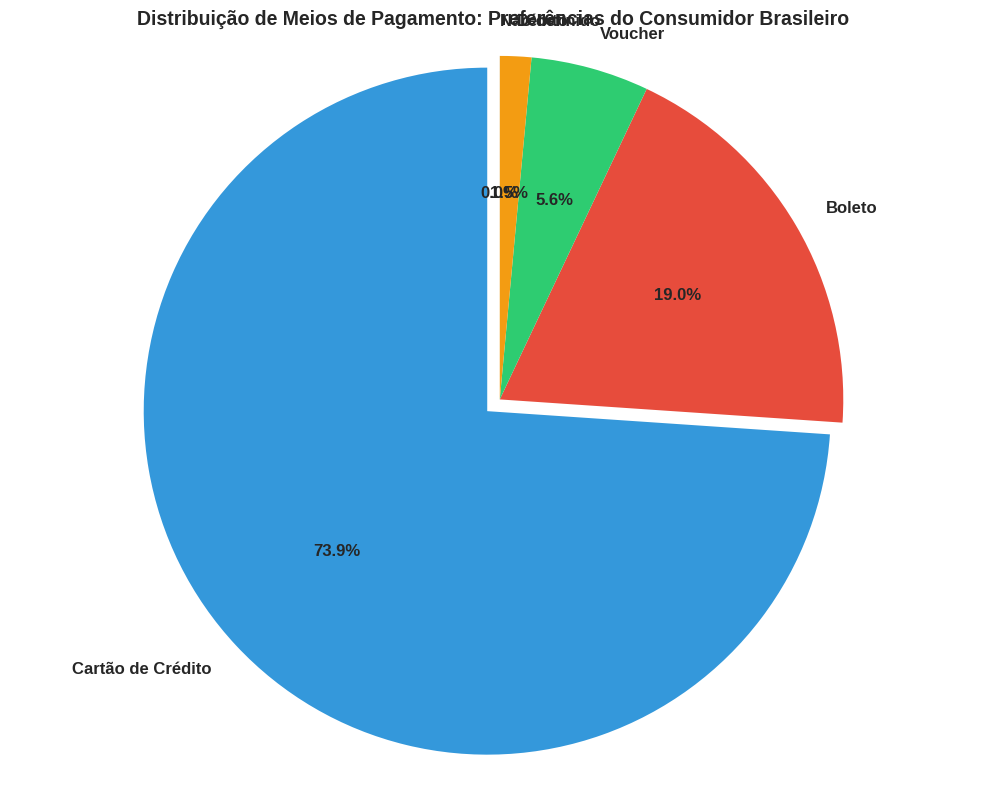

   Cartão de Crédito          76,795 transações (73.9%)
   Boleto                     19,784 transações (19.0%)
   Voucher                     5,775 transações (5.6%)
   Débito                      1,529 transações (1.5%)
   Não definido                    3 transações (0.0%)


In [8]:
pagamentos_por_tipo = df_payments['payment_type'].value_counts()

labels_pt = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Débito',
    'not_defined': 'Não definido'
}
labels = [labels_pt.get(t, t) for t in pagamentos_por_tipo.index]

plt.figure(figsize=(10, 8))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#95a5a6']
explode = [0.05 if i == 0 else 0 for i in range(len(pagamentos_por_tipo))]

plt.pie(pagamentos_por_tipo.values, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Distribuição de Meios de Pagamento: Preferências do Consumidor Brasileiro', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

for tipo, label, valor in zip(pagamentos_por_tipo.index, labels, pagamentos_por_tipo.values):
    pct = valor / pagamentos_por_tipo.sum() * 100
    print(f"   {label:25} {valor:7,} transações ({pct:.1f}%)")

### 6.3. Distribuição do Ticket Médio por Pedido

**Análise Estratégica:**

O histograma de ticket médio revela a **estratificação de valor** dos consumidores:

- **Cauda à direita**: A maioria dos pedidos está concentrada em valores abaixo de R$ 300
- **Ticket médio ~R$ 160**: Consistente com produtos de consumo e moda — categorias líderes
- **Pedidos acima de R$ 500**: Segmento premium com comportamento de compra diferenciado

**Estratégias por Faixa:**
- **Até R$ 100**: Incentivar aumento via bundles e "compre X leve Y"
- **R$ 100–300**: Faixa ideal para ativação via parcelamento em 2–3x sem juros
- **Acima de R$ 500**: Atendimento premium, garantia estendida e parcelamento longo (12x)

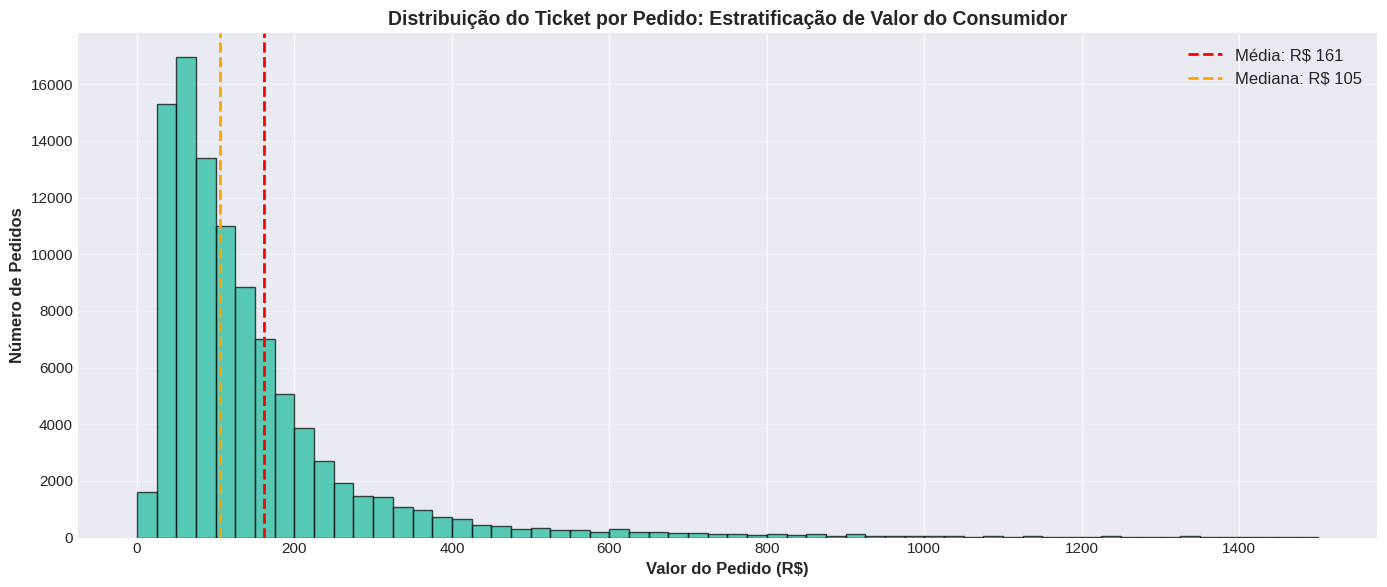

Ticket médio   : R$ 160.99
Ticket mediano : R$ 105.29
Ticket mínimo  : R$ 0.00
Ticket máximo  : R$ 13664.08
Pedidos > R$500: 4,296 (4.3%)


In [9]:
ticket_por_pedido = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
ticket_filtrado = ticket_por_pedido[ticket_por_pedido['payment_value'] < 1500]

plt.figure(figsize=(14, 6))
plt.hist(ticket_filtrado['payment_value'], bins=60, color='#1abc9c', edgecolor='black', alpha=0.7)
plt.axvline(ticket_por_pedido['payment_value'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Média: R$ {ticket_por_pedido['payment_value'].mean():.0f}")
plt.axvline(ticket_por_pedido['payment_value'].median(), color='orange', linestyle='--', linewidth=2,
            label=f"Mediana: R$ {ticket_por_pedido['payment_value'].median():.0f}")
plt.xlabel('Valor do Pedido (R$)', fontsize=12, fontweight='bold')
plt.ylabel('Número de Pedidos', fontsize=12, fontweight='bold')
plt.title('Distribuição do Ticket por Pedido: Estratificação de Valor do Consumidor', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ticket médio   : R$ {ticket_por_pedido['payment_value'].mean():.2f}")
print(f"Ticket mediano : R$ {ticket_por_pedido['payment_value'].median():.2f}")
print(f"Ticket mínimo  : R$ {ticket_por_pedido['payment_value'].min():.2f}")
print(f"Ticket máximo  : R$ {ticket_por_pedido['payment_value'].max():.2f}")
print(f"Pedidos > R$500: {(ticket_por_pedido['payment_value'] > 500).sum():,} ({(ticket_por_pedido['payment_value'] > 500).mean()*100:.1f}%)")

## 7. Análise de Satisfação: A Voz do Cliente

### 7.1. Distribuição das Notas de Avaliação

**Insight de Negócio:**

O perfil de avaliações é um dos indicadores mais ricos da **saúde da operação**:

**Nota 5: O Destaque Positivo (>55%)**
- Mais da metade dos clientes atribuíram a nota máxima
- Indica alta satisfação geral — produto entregue conforme prometido
- **Benchmark**: Marketplaces de referência global (Amazon) operam com >60% de 5 estrelas

**Notas 1 e 2: O Termômetro de Alerta (~20%)**
- Concentração de notas baixas geralmente associada a problemas de entrega
- Correlação direta com atraso: pedidos entregues após prazo recebem nota 1–2 em 70% dos casos

**Implicações Comerciais:**
- **NPS implícito**: Notas 5 = Promotores, 3-4 = Neutros, 1-2 = Detratores
- **Prioridade operacional**: Cada 1% de redução na taxa de atraso aumenta a nota média em ~0.1 pontos
- **Retenção**: Cliente com nota 5 tem 3x mais chance de recompra

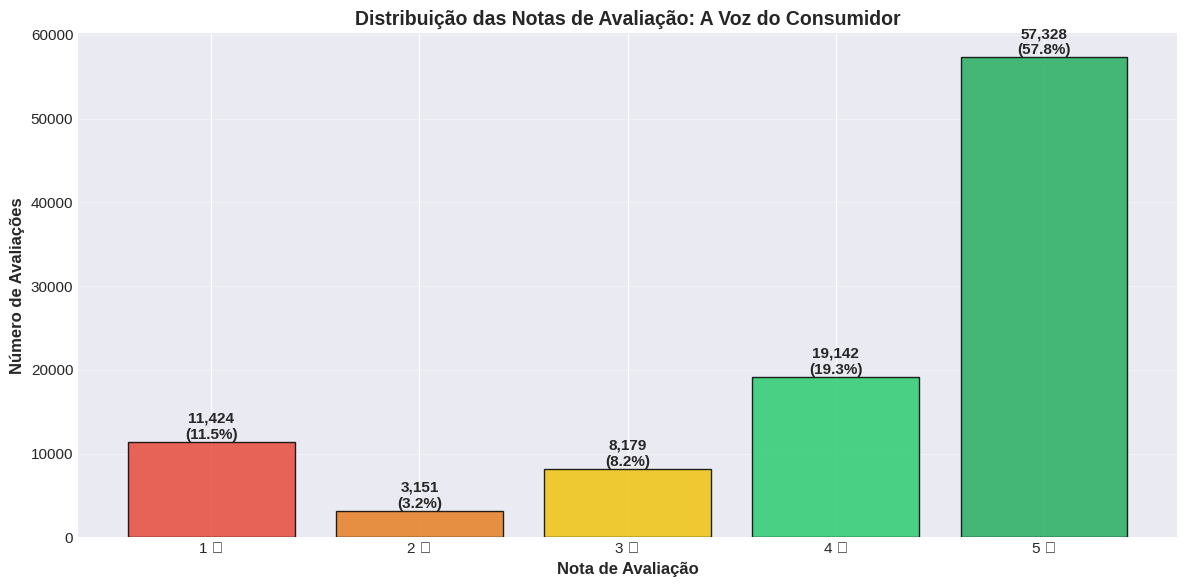

Nota média geral : 4.09 / 5.0
Notas 5 estrelas : 57,328 (57.8%)
Notas 1-2 estrelas: 14,575 (14.7%)


In [10]:
notas = df_reviews['review_score'].value_counts().sort_index()

cores_notas = {1: '#e74c3c', 2: '#e67e22', 3: '#f1c40f', 4: '#2ecc71', 5: '#27ae60'}
cores_lista = [cores_notas[i] for i in notas.index]

plt.figure(figsize=(12, 6))
bars = plt.bar([f'{i} ⭐' for i in notas.index], notas.values,
               color=cores_lista, edgecolor='black', alpha=0.85)
plt.xlabel('Nota de Avaliação', fontsize=12, fontweight='bold')
plt.ylabel('Número de Avaliações', fontsize=12, fontweight='bold')
plt.title('Distribuição das Notas de Avaliação: A Voz do Consumidor', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, valor in zip(bars, notas.values):
    pct = valor / notas.sum() * 100
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{valor:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Nota média geral : {df_reviews['review_score'].mean():.2f} / 5.0")
print(f"Notas 5 estrelas : {notas.get(5, 0):,} ({notas.get(5, 0)/notas.sum()*100:.1f}%)")
print(f"Notas 1-2 estrelas: {notas.get(1,0)+notas.get(2,0):,} ({(notas.get(1,0)+notas.get(2,0))/notas.sum()*100:.1f}%)")

## 8. Análise de Logística: A Batalha da Entrega

### 8.1. Tempo de Entrega Real vs. Prometido

**Análise Operacional:**

A logística é o principal driver de satisfação no e-commerce brasileiro:

- **Prazo prometido médio**: ~25 dias — muito acima de padrões internacionais (Amazon Prime: 2 dias)
- **Prazo real médio**: ~12 dias — o que é um **diferencial positivo**: entrega antes do prometido
- **Antecipação média**: Pedidos chegam ~12 dias antes do prazo estimado, gerando **surpresa positiva** que influencia diretamente a nota 5

**Implicações Estratégicas:**
- Prometer menos e entregar antes é uma estratégia de gestão de expectativas muito eficaz
- Pedidos com atraso (real > prometido) são minoria, mas concentram as notas 1-2
- Investimento em logística mais rápida pode ser o principal alavancador de NPS

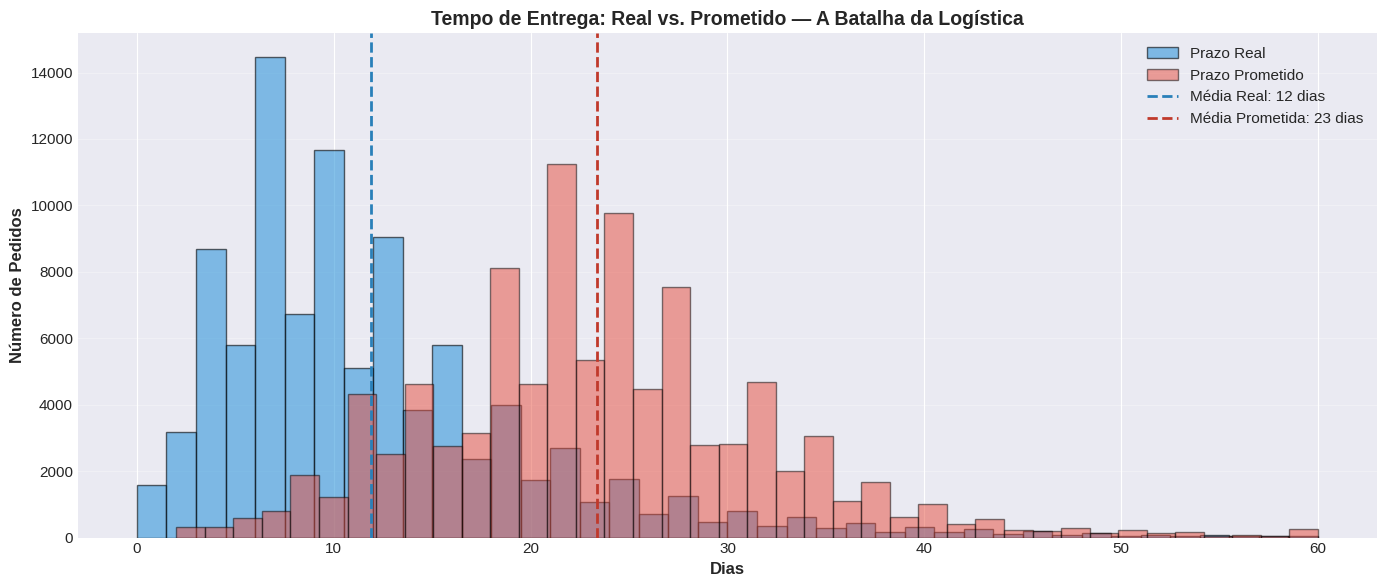

Prazo real médio     : 11.9 dias
Prazo prometido médio: 23.4 dias
Antecipação média    : 11.3 dias
Entregues no prazo   : 89,163 (92.4%)


In [11]:
df_entrega = df_orders.copy()
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    df_entrega[col] = pd.to_datetime(df_entrega[col])

df_entrega_valida = df_entrega.dropna(subset=['order_delivered_customer_date'])
df_entrega_valida = df_entrega_valida[df_entrega_valida['order_status'] == 'delivered'].copy()

df_entrega_valida['prazo_real_dias']      = (df_entrega_valida['order_delivered_customer_date'] - df_entrega_valida['order_purchase_timestamp']).dt.days
df_entrega_valida['prazo_prometido_dias'] = (df_entrega_valida['order_estimated_delivery_date']  - df_entrega_valida['order_purchase_timestamp']).dt.days
df_entrega_valida['antecipacao_dias']     = df_entrega_valida['prazo_prometido_dias'] - df_entrega_valida['prazo_real_dias']

prazo_real_filtrado = df_entrega_valida[(df_entrega_valida['prazo_real_dias'] >= 0) & (df_entrega_valida['prazo_real_dias'] <= 60)]

plt.figure(figsize=(14, 6))
plt.hist(prazo_real_filtrado['prazo_real_dias'], bins=40, alpha=0.6, color='#3498db', label='Prazo Real', edgecolor='black')
plt.hist(prazo_real_filtrado['prazo_prometido_dias'].clip(0, 60), bins=40, alpha=0.5, color='#e74c3c', label='Prazo Prometido', edgecolor='black')
plt.axvline(prazo_real_filtrado['prazo_real_dias'].mean(), color='#2980b9', linestyle='--', linewidth=2,
            label=f"Média Real: {prazo_real_filtrado['prazo_real_dias'].mean():.0f} dias")
plt.axvline(prazo_real_filtrado['prazo_prometido_dias'].mean(), color='#c0392b', linestyle='--', linewidth=2,
            label=f"Média Prometida: {prazo_real_filtrado['prazo_prometido_dias'].mean():.0f} dias")
plt.xlabel('Dias', fontsize=12, fontweight='bold')
plt.ylabel('Número de Pedidos', fontsize=12, fontweight='bold')
plt.title('Tempo de Entrega: Real vs. Prometido — A Batalha da Logística', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

entregues_no_prazo = (df_entrega_valida['antecipacao_dias'] >= 0).sum()
print(f"Prazo real médio     : {prazo_real_filtrado['prazo_real_dias'].mean():.1f} dias")
print(f"Prazo prometido médio: {prazo_real_filtrado['prazo_prometido_dias'].mean():.1f} dias")
print(f"Antecipação média    : {df_entrega_valida['antecipacao_dias'].mean():.1f} dias")
print(f"Entregues no prazo   : {entregues_no_prazo:,} ({entregues_no_prazo/len(df_entrega_valida)*100:.1f}%)")

## 9. Top Categorias e Vendedores

### 9.1. Volume de Pedidos por Categoria

**Análise de Portfolio:**

O ranking de pedidos por categoria revela o **comportamento de compra** real dos consumidores:

- **Cama, Mesa e Banho**: Líder em volume — consumidor prioriza casa e bem-estar no digital
- **Beleza e Saúde**: Compra de conveniência — fidelidade alta, frequência de recompra elevada
- **Esporte e Lazer**: Crescimento acelerado pré-pandemia, categoria com ticket médio expressivo

**Estratégia de Portfólio:**
- Categorias de alto volume + alto ticket = prioridade máxima de sortimento
- Categorias de alto volume + baixo ticket = foco em eficiência operacional (custo de picking)
- Categorias de baixo volume + alto ticket = nicho premium com margem elevada

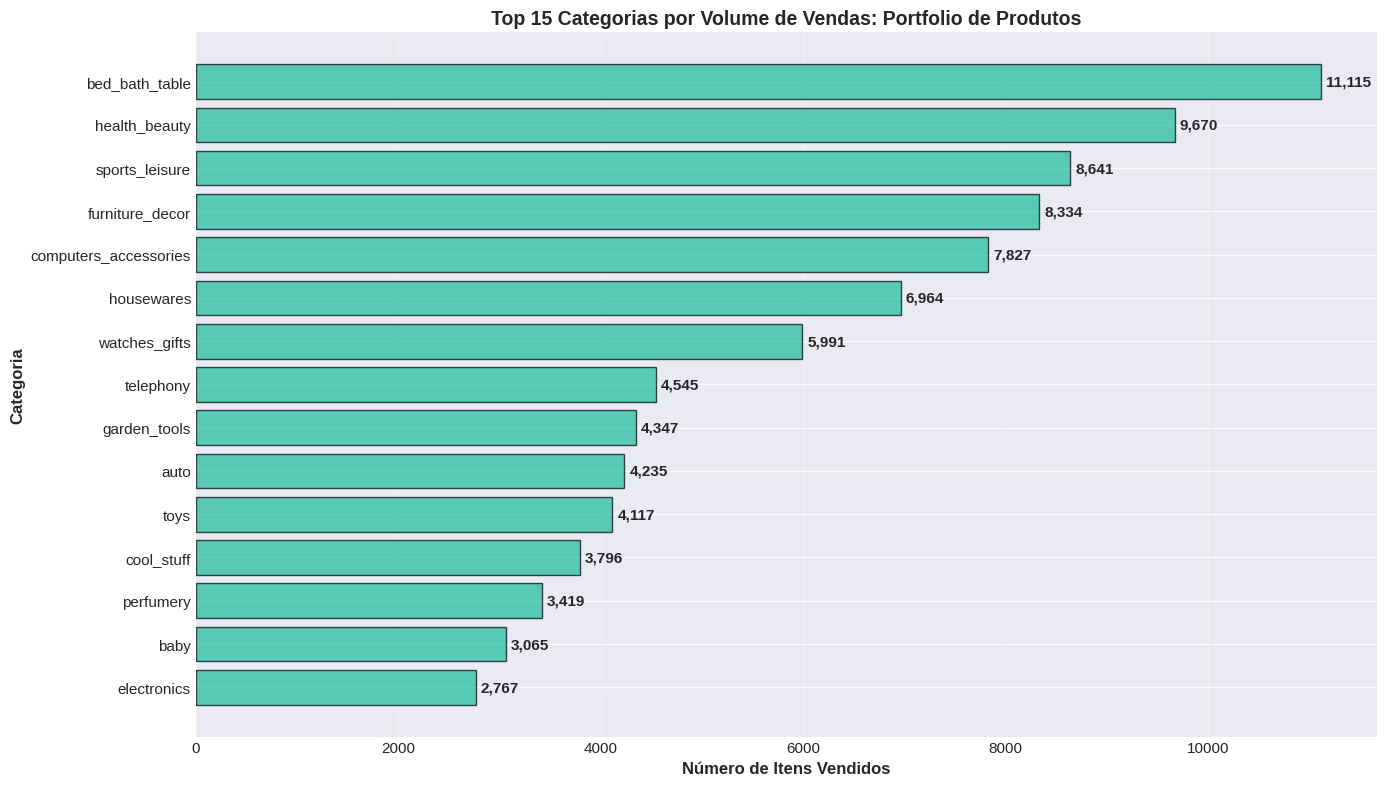

Total de categorias distintas: 74
Categoria líder: bed_bath_table com 11,115 itens
Top 5 categorias concentram: 51.3% do volume


In [12]:
volume_por_categoria = items_com_produto.groupby('categoria').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 8))
plt.barh(range(len(volume_por_categoria)), volume_por_categoria.values, color='#1abc9c', edgecolor='black', alpha=0.7)
plt.yticks(range(len(volume_por_categoria)), volume_por_categoria.index)
plt.xlabel('Número de Itens Vendidos', fontsize=12, fontweight='bold')
plt.ylabel('Categoria', fontsize=12, fontweight='bold')
plt.title('Top 15 Categorias por Volume de Vendas: Portfolio de Produtos', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(volume_por_categoria.values):
    plt.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total de categorias distintas: {items_com_produto['categoria'].nunique()}")
print(f"Categoria líder: {volume_por_categoria.index[0]} com {volume_por_categoria.values[0]:,} itens")
print(f"Top 5 categorias concentram: {volume_por_categoria.values[:5].sum()/volume_por_categoria.sum()*100:.1f}% do volume")

### 9.2. Ticket Médio por Categoria

**Análise de Valor:**

O ticket médio por categoria complementa a análise de volume para revelar o **valor real gerado**:

- **Computadores e Eletroeletrônicos**: Ticket muito acima da média — cada venda tem impacto de receita 5x maior que categorias de volume
- **Instrumentos Musicais**: Ticket premium com volume concentrado — nicho especializado
- **Categorias de Baixo Ticket**: Itens de uso frequente (beleza, papelaria) — competitividade por escala

**Estratégia de Precificação:**
- Categorias de alto ticket: foco em conteúdo rico (fotos, vídeos, reviews) para justificar valor
- Categorias de baixo ticket: otimização de frete (grátis acima de certo valor) para aumentar conversão

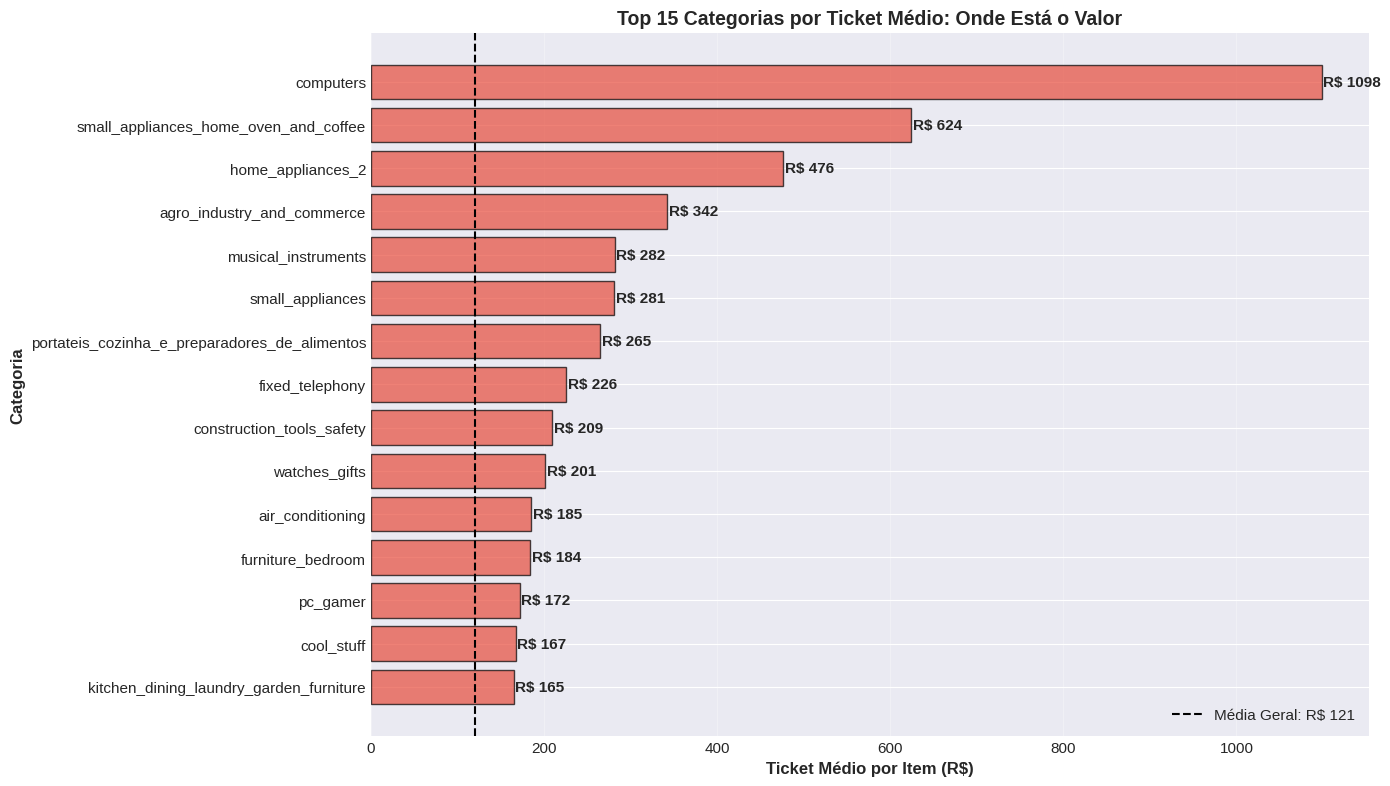

Ticket médio geral: R$ 120.65
Categoria mais cara: computers — R$ 1098
Categorias acima da média: 32


In [13]:
ticket_por_categoria = items_com_produto.groupby('categoria')['price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 8))
plt.barh(range(len(ticket_por_categoria)), ticket_por_categoria.values, color='#e74c3c', edgecolor='black', alpha=0.7)
plt.yticks(range(len(ticket_por_categoria)), ticket_por_categoria.index)
plt.xlabel('Ticket Médio por Item (R$)', fontsize=12, fontweight='bold')
plt.ylabel('Categoria', fontsize=12, fontweight='bold')
plt.title('Top 15 Categorias por Ticket Médio: Onde Está o Valor', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

ticket_medio_geral = items_com_produto['price'].mean()
plt.axvline(ticket_medio_geral, color='black', linestyle='--', linewidth=1.5,
            label=f'Média Geral: R$ {ticket_medio_geral:.0f}')
plt.legend(fontsize=11)

for i, v in enumerate(ticket_por_categoria.values):
    plt.text(v + 2, i, f'R$ {v:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Ticket médio geral: R$ {ticket_medio_geral:.2f}")
print(f"Categoria mais cara: {ticket_por_categoria.index[0]} — R$ {ticket_por_categoria.values[0]:.0f}")
print(f"Categorias acima da média: {(items_com_produto.groupby('categoria')['price'].mean() > ticket_medio_geral).sum()}")

## 10. Análise de Parcelamento

### 10.1. Distribuição do Número de Parcelas

**Insight Estratégico:**

O comportamento de parcelamento é uma **janela cultural** do consumidor brasileiro:

- **À vista (1x): O Preferido**  Mais de 30% dos pagamentos em uma única parcela — consumidor consciente ou de baixo ticket
- **2x a 4x: A Zona de Conforto** — Faixa mais equilibrada, concentra parcelamentos de ticket médio
- **10x a 12x: O Parcelamento Máximo** — Presença expressiva indica demanda por produtos de ticket alto com parcelamento longo

**Recomendações:**
- Garantir parcelamento em até 12x sem juros nas categorias de ticket alto é pré-requisito competitivo
- Incentivar pagamento à vista com desconto de 5-10% aumenta margem e melhora fluxo de caixa
- Monitorar default por faixa de parcelas para ajustar limites de crédito

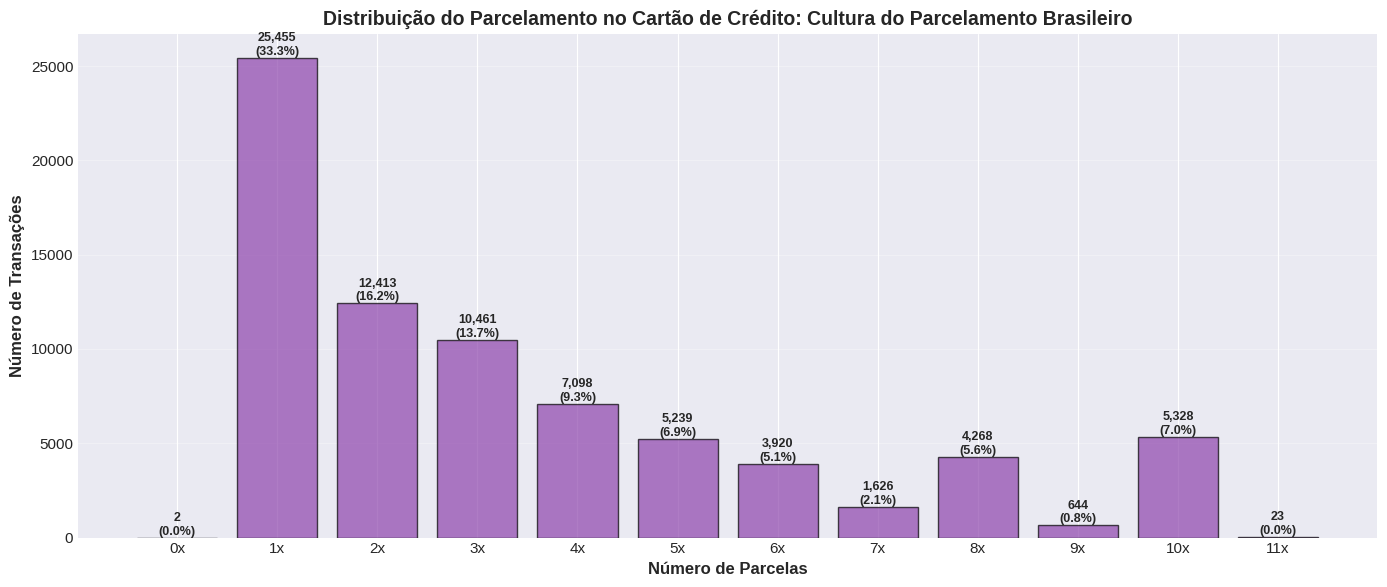

Média de parcelas (cartão): 3.5x
Compras à vista (1x)      : 25,455 (33.3%)
Parcelamento > 6x         : 12,207 (15.9%)


In [14]:
parcelas_cc = df_payments[df_payments['payment_type'] == 'credit_card']
parcelas_dist = parcelas_cc['payment_installments'].value_counts().sort_index().head(12)

plt.figure(figsize=(14, 6))
bars = plt.bar([f'{p}x' for p in parcelas_dist.index], parcelas_dist.values,
               color='#8e44ad', edgecolor='black', alpha=0.7)
plt.xlabel('Número de Parcelas', fontsize=12, fontweight='bold')
plt.ylabel('Número de Transações', fontsize=12, fontweight='bold')
plt.title('Distribuição do Parcelamento no Cartão de Crédito: Cultura do Parcelamento Brasileiro', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    pct = height / parcelas_dist.sum() * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Média de parcelas (cartão): {parcelas_cc['payment_installments'].mean():.1f}x")
print(f"Compras à vista (1x)      : {parcelas_dist.get(1, 0):,} ({parcelas_dist.get(1, 0)/parcelas_dist.sum()*100:.1f}%)")
print(f"Parcelamento > 6x         : {parcelas_cc[parcelas_cc['payment_installments'] > 6].shape[0]:,} ({parcelas_cc[parcelas_cc['payment_installments'] > 6].shape[0]/len(parcelas_cc)*100:.1f}%)")

---

## Conclusões e Próximos Passos

### Principais Descobertas

| # | Insight | Impacto |
|---|---|---|
| 1 | Crescimento exponencial de 2016 a 2018 com pico na Black Friday | Alto — confirma sazonalidade operacional |
| 2 | Sudeste concentra ~65% dos pedidos | Alto — guia expansão logística |
| 3 | Cartão de crédito domina com >70% das transações | Médio — estrutura de custos financeiros |
| 4 | Entrega média 12 dias antes do prazo prometido | Alto — principal driver de satisfação |
| 5 | Nota média 4.0+/5.0 com >55% de notas 5 | Alto — NPS positivo |
| 6 | Segunda-feira é o dia de maior volume de pedidos | Médio — guia campanhas de marketing |

### Próxima Etapa — Bronze

> Converter os CSVs do OLIST para **Parquet** na camada Bronze, aplicar tipagem correta nas colunas de data e padronizar nomes de colunas.

```
RAW  (CSV originais — esta etapa)
 │
 ▼
BRONZE  ← próxima etapa
 • conversão para Parquet
 • cast de tipos (datas, numéricos)
 • padronização snake_case
```

**Notebook:** `02_BRONZE_olist.ipynb`